# CS5480: Lightweight QA Evaluation with FLAN-T5

## Problem Overview
Large Language Models often hallucinate because they optimize for plausible text rather than factual correctness. This notebook establishes a closed-book baseline for question answering, which will later be compared against retrieval-augmented approaches.

The goal is to measure how well a model can answer questions without external context.

### 1. Imports

In [35]:
# !pip install pandas numpy transformers rank-bm25 collections sentence-transformers

import pandas as pd
import numpy as np
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from rank_bm25 import BM25Okapi
from collections import Counter
from sentence_transformers import SentenceTransformer

## Dataset Description
The dataset consists of:
- `question`: input query
- `short_answers`: ground truth answer
- `long_answers`:

This format enables straightforward evaluation using exact string matching and token overlap metrics.

### 2. Load Dataset Function

In [37]:
df = pd.read_csv("./Natural-Questions-Filtered.csv")

QUESTIONS = df["question"].tolist()
GROUND_TRUTH = df["short_answers"].tolist()
CORPUS = df["long_answers"].tolist()

### 3. Load Model

In [38]:
model_name = "google/flan-t5-small"
TOKENIZER = AutoTokenizer.from_pretrained(model_name)
MODEL = AutoModelForSeq2SeqLM.from_pretrained(model_name)

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


### 4. Define Analysis Functions

In [39]:
def generate_answer(question):
    prompt = f"Answer the question: {question}"

    inputs = TOKENIZER(prompt, return_tensors="pt", truncation=True)
    outputs = MODEL.generate(**inputs, max_length=64)

    return TOKENIZER.decode(outputs[0], skip_special_tokens=True)

def exact_match(pred, truth):
    return int(pred.strip().lower() == truth.strip().lower())

def f1_score(pred, truth):
    pred_tokens = pred.lower().split()
    truth_tokens = truth.lower().split()

    pred_counts = Counter(pred_tokens)
    truth_counts = Counter(truth_tokens)

    common = sum((pred_counts & truth_counts).values())

    if common == 0:
        return 0.0

    precision = common/len(pred_tokens)
    recall = common/len(truth_tokens)

    return 2 * (precision * recall) / (precision + recall)

### 5. Define Experiment Loop

In [40]:
def run_experiment(retrieve_fn=None, k=3, limit=100):
    em_scores, f1_scores = [], []

    for i in range(min(limit, len(QUESTIONS))):
        q = QUESTIONS[i]
        truth = GROUND_TRUTH[i]

        # retrieval step
        if retrieve_fn is not None:
            contexts = retrieve_fn(q, k)   # returns list of passages
            context_str = " ".join(contexts)
            prompt = f"Answer the question using the context:\n{context_str}\n\nQuestion: {q}"
        else:
            prompt = f"Answer the question: {q}"

        # generation
        inputs = TOKENIZER(prompt, return_tensors="pt", truncation=True)
        outputs = MODEL.generate(**inputs, max_length=64)
        pred = TOKENIZER.decode(outputs[0], skip_special_tokens=True)

        # evaluation
        em_scores.append(exact_match(pred, truth))
        f1_scores.append(f1_score(pred, truth))

    return np.mean(em_scores), np.mean(f1_scores)

### 6. Find Baseline Performance
We will identify the baseline performance by prompting our model with no regression techniques applied. This way, we can determine if BM25, dense, or hybrid retrieval actually improve model performance.

In [41]:
print("Running baseline...")
em, f1 = run_experiment() # no retrieve_fn

print("\n=== BASELINE RESULTS ===")
print(f"Exact Match Score: {em:.4f}")
print(f"F1 Score: {f1:.4f}")

Running baseline...

=== BASELINE RESULTS ===
Exact Match Score: 0.0200
F1 Score: 0.0670


### 7. Find BM25 Performance

**First, we'll build an index for the answer corpus**

In [42]:
TOKENIZED_CORPUS = [doc.split() for doc in CORPUS]
BM25 = BM25Okapi(TOKENIZED_CORPUS)

**Then, we'll define the retrieval function**

In [43]:
def bm25_retrieve(query, k=3):
    tokenized_query = query.split()

    scores = BM25.get_scores(tokenized_query)
    top_k_idx = np.argsort(scores)[-k:][::-1]

    return [CORPUS[i] for i in top_k_idx]

**Finally, we find the BM25 performance.**

In [44]:
print("Running BM25 experiment...")
em, f1 = run_experiment(retrieve_fn=bm25_retrieve)

print("\n=== BM25 RESULTS ===")
print(f"Exact Match Score: {em:.4f}")
print(f"F1 Score: {f1:.4f}")

Running BM25 experiment...

=== BM25 RESULTS ===
Exact Match Score: 0.0300
F1 Score: 0.0879


### 8. Find Dense Retrieval Performance

**First, we build the embeddings for dense retrieval**

In [45]:
EMBED_MODEL = SentenceTransformer("all-MiniLM-L6-v2")

CORPUS_EMBEDDINGS = EMBED_MODEL.encode(
    CORPUS,
    batch_size=32,
    convert_to_numpy=True
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


**Then, we define the retrieval function**

In [46]:
def dense_retrieve(query, k=3):
    query_emb = EMBED_MODEL.encode(query, convert_to_numpy=True)

    scores = np.dot(CORPUS_EMBEDDINGS, query_emb)
    top_k_idx = np.argsort(scores)[-k:][::-1]

    return [CORPUS[i] for i in top_k_idx]

**Finally, we'll run the experiment**

In [47]:
print("Running dense experiment...")
em, f1 = run_experiment(retrieve_fn=dense_retrieve)

print("\n=== DENSE RESULTS ===")
print(f"Exact Match Score: {em:.4f}")
print(f"F1 Score: {f1:.4f}")

Running dense experiment...

=== DENSE RESULTS ===
Exact Match Score: 0.1900
F1 Score: 0.2812


### 9. Find Hybrid Retrieval Performance

**First we need methods to get the BM25 and Dense scores**

In [48]:
def bm25_scores(query):
    tokenized_query = query.split()
    return BM25.get_scores(tokenized_query)

def dense_scores(query):
    query_emb = EMBED_MODEL.encode(query, convert_to_numpy=True, normalize_embeddings=True)
    return np.dot(CORPUS_EMBEDDINGS, query_emb)

**Next, let's define our hybrid retrieval function**

In [51]:
def hybrid_retrieve(query, k=3, alpha=0.5):
    bm25 = bm25_scores(query)

    dense = dense_scores(query)

    #normalize scores to [0,1]
    bm25 = (bm25 - bm25.min()) / (bm25.max() - bm25.min() + 1e-8)
    dense = (dense - dense.min()) / (dense.max() - dense.min() + 1e-8)

    #combine scores
    combined = alpha * dense + (1 - alpha) * bm25

    top_k_idx = np.argsort(combined)[-k:][::-1]

    return [CORPUS[i] for i in top_k_idx]

**And finally, let's find our hybrid results**

In [52]:
print("Running hybrid experiment...")
em, f1 = run_experiment(retrieve_fn=hybrid_retrieve)

print("\n=== HYBRID RESULTS ===")
print(f"Exact Match Score: {em:.4f}")
print(f"F1 Score: {f1:.4f}")

Running hybrid experiment...

=== HYBRID RESULTS ===
Exact Match Score: 0.0700
F1 Score: 0.1397


**Just for fun, let's see how different alpha-values compare**

In [53]:
for a in [0.2, 0.5, 0.8]:
    print(f"\nAlpha = {a}")
    em, f1 = run_experiment(lambda q, k: hybrid_retrieve(q, k, alpha=a))
    print(f"EM: {em:.4f}, F1: {f1:.4f}")


Alpha = 0.2
EM: 0.0300, F1: 0.0787

Alpha = 0.5
EM: 0.0700, F1: 0.1397

Alpha = 0.8
EM: 0.1700, F1: 0.2372


### 10. Comparison and Analysis

In [55]:
import pandas as pd

data = {
    "Method": [
        "Baseline",
        "BM25",
        "Dense",
        "Hybrid (a=0.2)",
        "Hybrid (a=0.5)",
        "Hybrid (a=0.8)"
    ],
    "EM": [0.02, 0.03, 0.19, 0.03, 0.07, 0.17],
    "F1": [0.07, 0.088, 0.281, 0.079, 0.140, 0.237]
}

df_results = pd.DataFrame(data)
print(df_results)

           Method    EM     F1
0        Baseline  0.02  0.070
1            BM25  0.03  0.088
2           Dense  0.19  0.281
3  Hybrid (a=0.2)  0.03  0.079
4  Hybrid (a=0.5)  0.07  0.140
5  Hybrid (a=0.8)  0.17  0.237


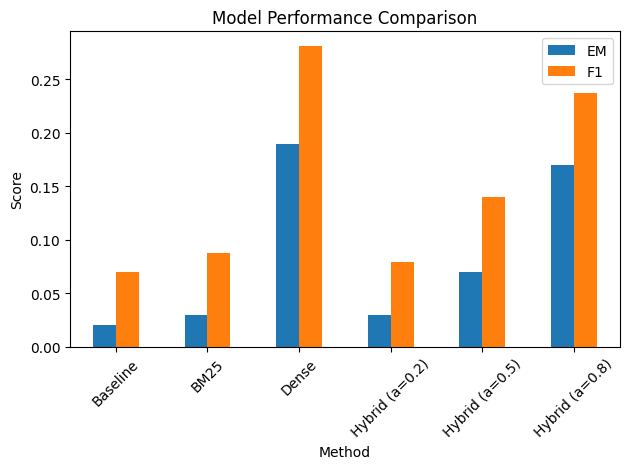

In [56]:
import matplotlib.pyplot as plt

df_results.set_index("Method")[["EM", "F1"]].plot(kind="bar")
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

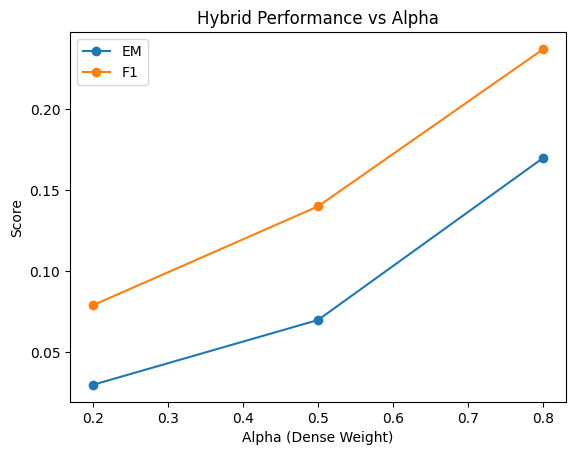

In [60]:
hybrid_df = df_results[df_results["Method"].str.contains("Hybrid")].copy()
hybrid_df["alpha"] = [0.2, 0.5, 0.8]

plt.plot(hybrid_df["alpha"], hybrid_df["EM"], marker='o', label="EM")
plt.plot(hybrid_df["alpha"], hybrid_df["F1"], marker='o', label="F1")

plt.title("Hybrid Performance vs Alpha")
plt.xlabel("Alpha (Dense Weight)")
plt.ylabel("Score")
plt.legend()
plt.show()